# NASA POWER — Data Understanding & Exploration

**Regions:** Peninsular Malaysia · East Malaysia · USA  
**Sources:** SYN1DEG (solar) + MERRA2 (meteorological) via public AWS S3  
**Flow:** S3 connection → dataset inspection → region extraction → aggregation → data exploration

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import s3fs
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde


## 2. Connect to NASA POWER S3 Bucket

In [2]:
fs = s3fs.S3FileSystem(anon=True)

SYN1DEG_DAILY = (
    "s3://nasa-power/syn1deg/temporal/"
    "power_syn1deg_daily_temporal_utc.zarr"
)
MERRA2_DAILY = (
    "s3://nasa-power/merra2/temporal/"
    "power_merra2_daily_temporal_utc.zarr"
)

syn_ds   = xr.open_zarr(SYN1DEG_DAILY, storage_options={"anon": True})
merra_ds = xr.open_zarr(MERRA2_DAILY,  storage_options={"anon": True})
print("Datasets loaded successfully.")

Datasets loaded successfully.


## 3. Dataset Inspection

### 3.1 Available Variables

In [3]:
syn1deg_variables  = list(syn_ds.data_vars)
merra2_variables   = list(merra_ds.data_vars)
print("SYN1DEG Variables:\n", syn1deg_variables)
print("\nMERRA2 Variables:\n",  merra2_variables)

SYN1DEG Variables:
 ['AIRMASS', 'ALLSKY_KT', 'ALLSKY_NKT', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_LW_UP', 'ALLSKY_SFC_PAR_DIFF', 'ALLSKY_SFC_PAR_DIRH', 'ALLSKY_SFC_PAR_TOT', 'ALLSKY_SFC_SW_DIFF', 'ALLSKY_SFC_SW_DIRH', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_UP', 'ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SRF_ALB', 'AOD_55', 'AOD_55_ADJ', 'AOD_84', 'CLOUD_AMT', 'CLOUD_AMT_DAY', 'CLOUD_AMT_NIGHT', 'CLOUD_OD', 'CLRSKY_DAYS', 'CLRSKY_KT', 'CLRSKY_NKT', 'CLRSKY_SFC_LW_DWN', 'CLRSKY_SFC_LW_UP', 'CLRSKY_SFC_PAR_DIFF', 'CLRSKY_SFC_PAR_DIRH', 'CLRSKY_SFC_PAR_TOT', 'CLRSKY_SFC_SW_DIFF', 'CLRSKY_SFC_SW_DIRH', 'CLRSKY_SFC_SW_DNI', 'CLRSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_UP', 'CLRSKY_SRF_ALB', 'MIDDAY_INSOL', 'ORIGINAL_ALLSKY_SFC_SW_DIFF', 'ORIGINAL_ALLSKY_SFC_SW_DIRH', 'PSH', 'PW', 'SRF_ALB_ADJ', 'TOA_SW_DNI', 'TOA_SW_DWN', 'TS_ADJ']

MERRA2 Variables:
 ['CDD0', 'CDD10', 'CDD18_3', 'DISPH', 'EVLAND', 'EVPTRNS', 'FROST_DAYS', 'FRSEAICE', 'FRSNO', 'GWETPROF', 'GWETROOT

### 3.2 Dimensions

In [4]:
print("SYN1DEG Dimensions:", list(syn_ds.dims))
print("MERRA2  Dimensions:", list(merra_ds.dims))

SYN1DEG Dimensions: ['time', 'lat', 'lon']
MERRA2  Dimensions: ['time', 'lat', 'lon']


## 4. Region Configuration

In [5]:
COUNTRY_BOUNDS = {
    "Peninsular Malaysia": {"lat_min": 1,    "lat_max": 8,    "lon_min": 98,   "lon_max": 105},
    "East Malaysia":       {"lat_min": 1,    "lat_max": 7,    "lon_min": 108,  "lon_max": 120},
    "USA":                 {"lat_min": 24.5, "lat_max": 49.5, "lon_min": -125, "lon_max": -66.9},
}

def select_region(ds, bounds):
    """Slice an xarray Dataset/DataArray to a lat/lon bounding box."""
    return ds.sel(
        lat=slice(bounds["lat_min"], bounds["lat_max"]),
        lon=slice(bounds["lon_min"], bounds["lon_max"])
    )

print("Regions defined:", list(COUNTRY_BOUNDS.keys()))

Regions defined: ['Peninsular Malaysia', 'East Malaysia', 'USA']


## 5. Variable Selection

| Variable | Source | Description |
|----------|--------|-------------|
| `ALLSKY_SFC_SW_DWN` | SYN1DEG | GHI — **target variable** |
| `CLOUD_AMT` | SYN1DEG | Cloud amount (%) |
| `AOD_55` | SYN1DEG | Aerosol optical depth |
| `PW` | SYN1DEG | Precipitable water |
| `ALLSKY_KT` | SYN1DEG | Clearness index |
| `PSH` | SYN1DEG | Peak sun hours |
| `RH2M` | MERRA2 | Relative humidity at 2 m |
| `WS2M` | MERRA2 | Wind speed at 2 m |
| `T2M_MAX` | MERRA2 | Max temperature at 2 m |
| `PS` | MERRA2 | Surface pressure |

In [6]:
SYN1DEG_VARS = ["ALLSKY_SFC_SW_DWN", "CLOUD_AMT", "AOD_55", "PW", "ALLSKY_KT", "PSH"]
MERRA2_VARS  = ["RH2M", "WS2M", "T2M_MAX", "PS"]
ALL_VARS = SYN1DEG_VARS + MERRA2_VARS
print("Selected SYN1DEG vars:", SYN1DEG_VARS)
print("Selected MERRA2  vars:", MERRA2_VARS)

Selected SYN1DEG vars: ['ALLSKY_SFC_SW_DWN', 'CLOUD_AMT', 'AOD_55', 'PW', 'ALLSKY_KT', 'PSH']
Selected MERRA2  vars: ['RH2M', 'WS2M', 'T2M_MAX', 'PS']


## 6. Data Extraction and Spatial Aggregation

For each region, variables are spatially averaged (mean over lat/lon) to produce daily time series.

In [7]:
region_dfs = {}

for region, bounds in COUNTRY_BOUNDS.items():
    syn_data   = {v: select_region(syn_ds[v],   bounds).mean(dim=["lat","lon"]).to_series() for v in SYN1DEG_VARS}
    merra_data = {v: select_region(merra_ds[v], bounds).mean(dim=["lat","lon"]).to_series() for v in MERRA2_VARS}
    df = pd.DataFrame({**syn_data, **merra_data})
    df.index.name = "time"
    df = df.dropna()
    region_dfs[region] = df
    print(f"{region}: {df.shape[0]} days, {df.shape[1]} features")

region_dfs["Peninsular Malaysia"].head()

Peninsular Malaysia: 9132 days, 10 features
East Malaysia: 9132 days, 10 features
USA: 9132 days, 10 features


,ALLSKY_SFC_SW_DWN,CLOUD_AMT,AOD_55,PW,ALLSKY_KT,PSH,RH2M,WS2M,T2M_MAX,PS
time,,,,,,,,,,
2000-12-31,111.924881,92.492645,0.322048,5.584084,0.287145,2.686333,88.016388,3.208558,26.875835,997.647461
2001-01-01,172.543488,90.471001,0.302859,5.429185,0.443673,4.140611,85.960884,3.491946,26.975391,997.580750
2001-01-02,149.142242,92.644081,0.380615,5.275720,0.384493,3.579591,85.759613,2.887557,26.564445,998.365295
2001-01-03,164.982239,92.725105,0.441635,5.185301,0.424081,3.959594,84.925163,2.633500,26.364002,998.987671
2001-01-04,136.036316,90.428154,0.462861,5.207554,0.348162,3.265097,83.733002,2.485108,26.685835,999.212402


## 7. Data Exploration

### 7.1 Temporal Coverage

In [8]:
print(f"{'Region':<25} {'Start':^12} {'End':^12} {'Days':>6}")
print('-' * 60)
for region, df in region_dfs.items():
    print(f"{region:<25} {str(df.index.min().date()):^12} "
          f"{str(df.index.max().date()):^12} {len(df):>6}")

Region                       Start         End        Days
------------------------------------------------------------
Peninsular Malaysia        2000-12-31   2025-12-31    9132
East Malaysia              2000-12-31   2025-12-31    9132
USA                        2000-12-31   2025-12-31    9132


### 7.2 Descriptive Statistics — Peninsular Malaysia

In [9]:
stats = region_dfs["Peninsular Malaysia"].describe().T
stats["skew"]     = region_dfs["Peninsular Malaysia"].skew()
stats["kurtosis"] = region_dfs["Peninsular Malaysia"].kurtosis()
stats.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ALLSKY_SFC_SW_DWN,9132.0,205.176,33.780,85.590,183.496,208.382,229.284,286.998,-0.452,-0.061
CLOUD_AMT,9132.0,82.061,15.275,19.248,73.777,86.578,94.211,99.660,-1.159,0.899
AOD_55,9132.0,0.380,0.146,0.156,0.307,0.355,0.414,3.073,5.806,59.444
PW,9132.0,5.229,0.508,2.546,4.983,5.318,5.552,6.776,-0.944,1.680
ALLSKY_KT,9132.0,0.495,0.076,0.203,0.447,0.505,0.551,0.671,-0.573,0.025
PSH,9132.0,4.924,0.811,2.055,4.404,5.001,5.503,6.888,-0.452,-0.061
RH2M,9132.0,83.132,2.381,73.291,81.528,83.113,84.754,90.524,-0.033,-0.112
WS2M,9132.0,2.387,0.639,1.073,1.910,2.283,2.778,5.081,0.715,0.259
T2M_MAX,9132.0,28.633,0.789,26.026,28.087,28.644,29.168,31.407,0.080,-0.062
PS,9132.0,998.567,1.383,994.037,997.646,998.506,999.407,1004.885,0.276,0.462


### 7.3 Missing Value Analysis

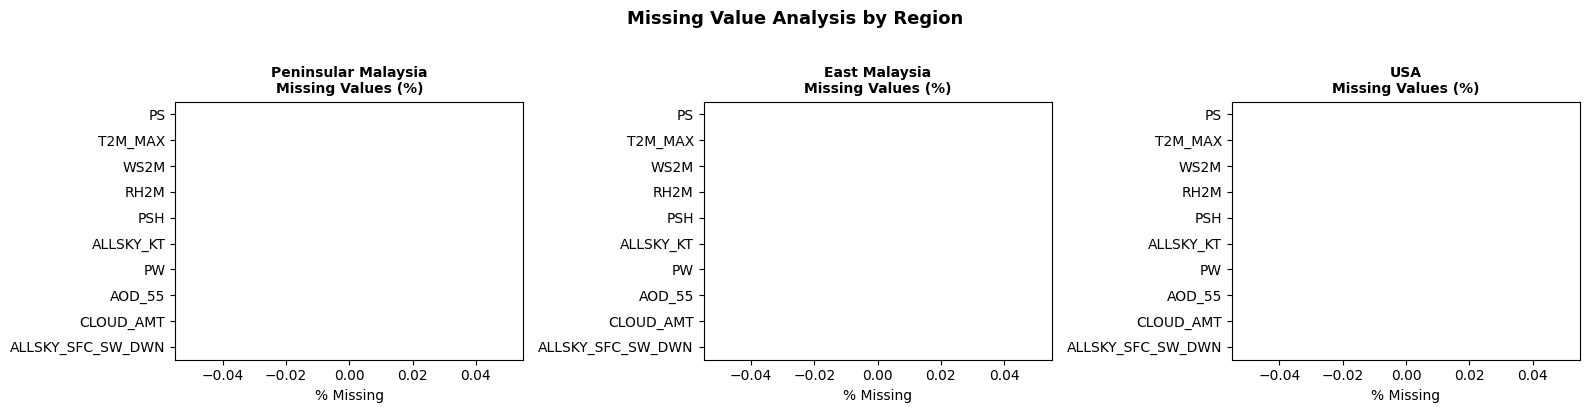

In [10]:
COLORS = ["#2ECC71", "#3498DB", "#E67E22"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (region, df), color in zip(axes, region_dfs.items(), COLORS):
    pct = df.isnull().mean() * 100
    pct.plot(kind="barh", ax=ax, color="#E74C3C", edgecolor="white")
    ax.set_title(f"{region}\nMissing Values (%)", fontsize=10, fontweight="bold")
    ax.set_xlabel("% Missing")
plt.suptitle("Missing Value Analysis by Region", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 7.4 GHI Time-Series by Region

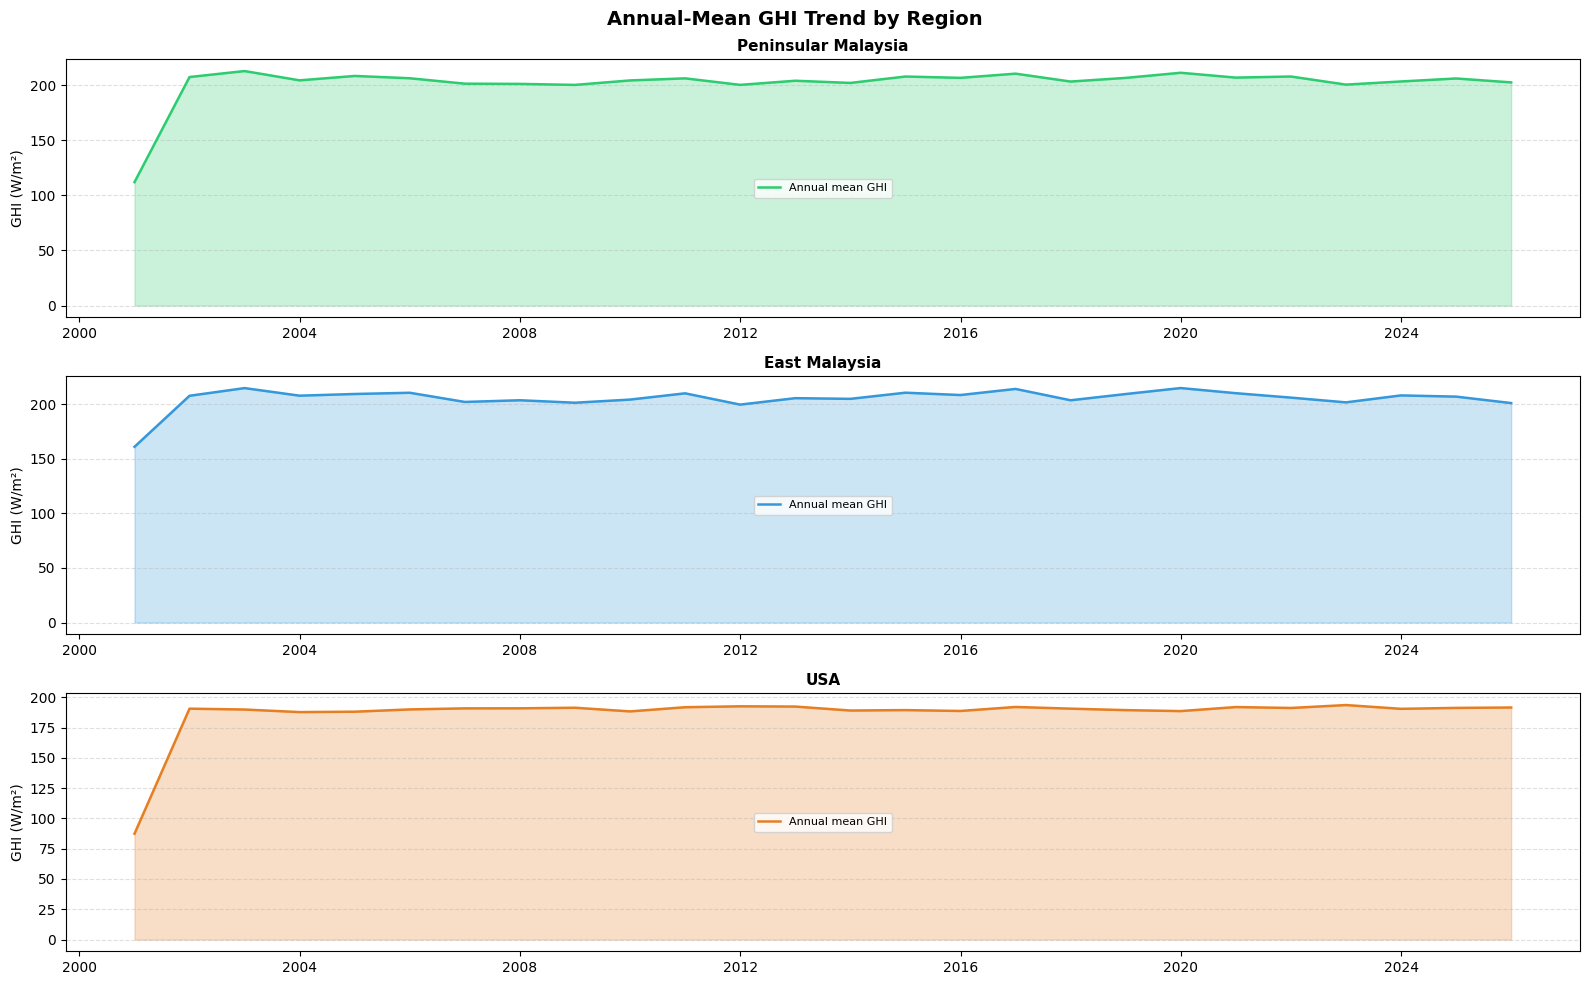

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
for ax, (region, df), color in zip(axes, region_dfs.items(), COLORS):
    annual = df["ALLSKY_SFC_SW_DWN"].resample("YE").mean()
    ax.fill_between(annual.index, annual.values, alpha=0.25, color=color)
    ax.plot(annual.index, annual.values, color=color, lw=1.8, label="Annual mean GHI")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("GHI (W/m²)"); ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.suptitle("Annual-Mean GHI Trend by Region", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 7.5 Monthly GHI Seasonality

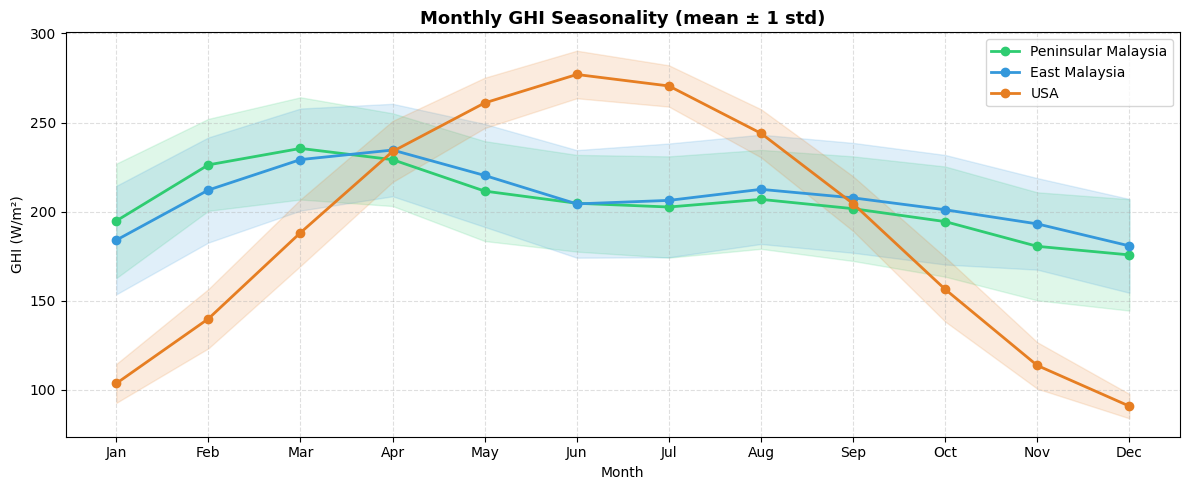

In [12]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 5))
for (region, df), color in zip(region_dfs.items(), COLORS):
    m = df["ALLSKY_SFC_SW_DWN"].groupby(df.index.month).agg(["mean","std"])
    ax.plot(m.index, m["mean"], marker="o", label=region, color=color, lw=2)
    ax.fill_between(m.index, m["mean"]-m["std"], m["mean"]+m["std"], alpha=0.15, color=color)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel("Month"); ax.set_ylabel("GHI (W/m²)")
ax.set_title("Monthly GHI Seasonality (mean ± 1 std)", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### 7.6 GHI Distribution per Region

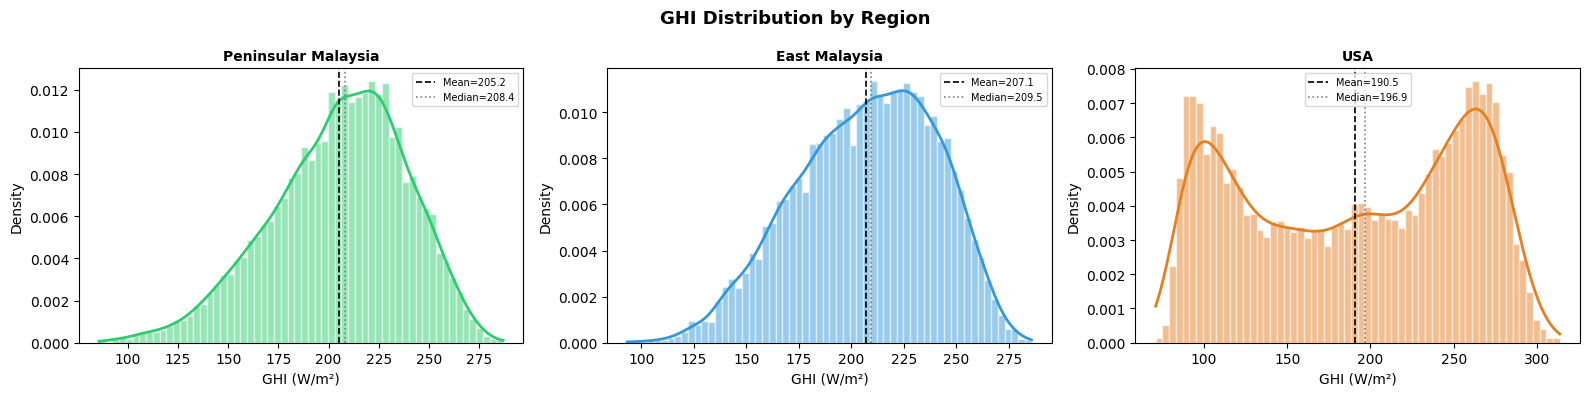

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (region, df), color in zip(axes, region_dfs.items(), COLORS):
    data = df["ALLSKY_SFC_SW_DWN"].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.5, color=color, edgecolor="white")
    kde = gaussian_kde(data)
    xs  = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), color=color, lw=2)
    ax.axvline(data.mean(),   color="black", lw=1.2, linestyle="--", label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="gray",  lw=1.2, linestyle=":",  label=f"Median={data.median():.1f}")
    ax.set_title(region, fontsize=10, fontweight="bold")
    ax.set_xlabel("GHI (W/m²)"); ax.set_ylabel("Density"); ax.legend(fontsize=7)
plt.suptitle("GHI Distribution by Region", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 7.7 Correlation Heatmap — Peninsular Malaysia

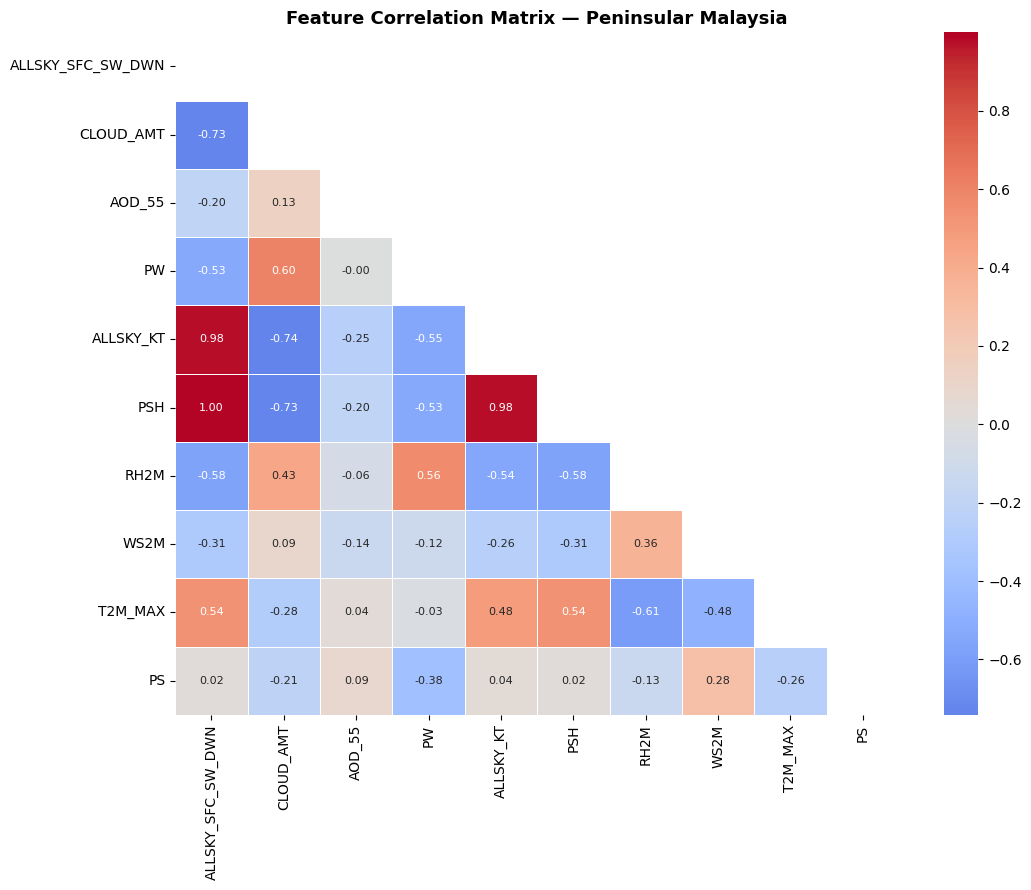

In [14]:
corr = region_dfs["Peninsular Malaysia"].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix — Peninsular Malaysia", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 7.8 GHI vs Key Predictors — Peninsular Malaysia

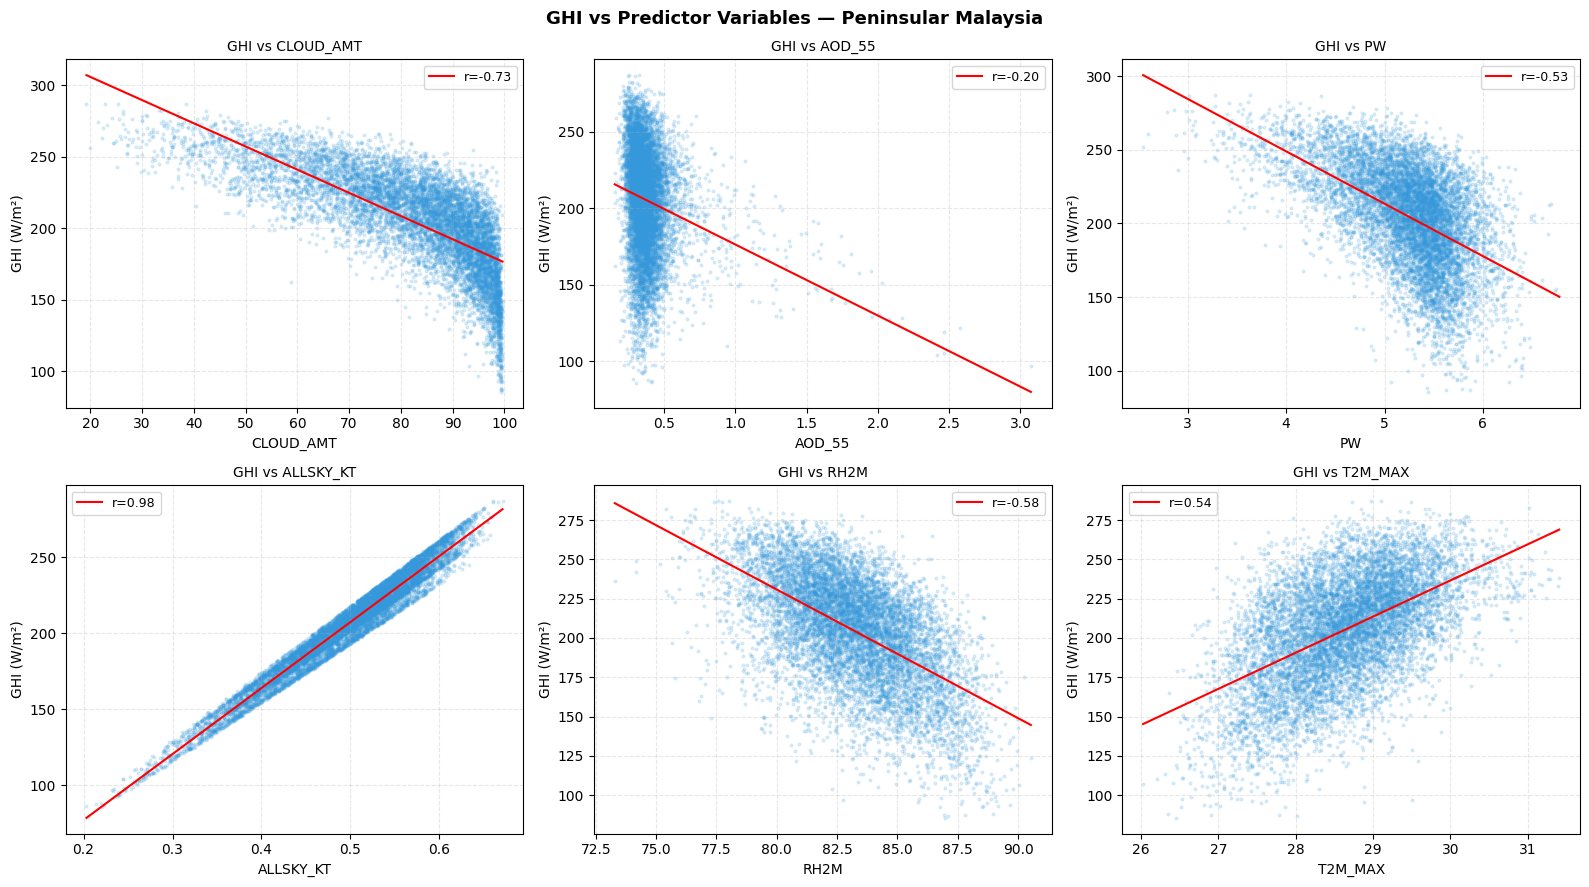

In [15]:
TARGET     = "ALLSKY_SFC_SW_DWN"
PREDICTORS = ["CLOUD_AMT", "AOD_55", "PW", "ALLSKY_KT", "RH2M", "T2M_MAX"]
df_pm = region_dfs["Peninsular Malaysia"].dropna()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, pred in zip(axes.flat, PREDICTORS):
    ax.scatter(df_pm[pred], df_pm[TARGET], alpha=0.15, s=4, color="#3498DB", rasterized=True)
    m, b = np.polyfit(df_pm[pred].values, df_pm[TARGET].values, 1)
    xs = np.array([df_pm[pred].min(), df_pm[pred].max()])
    r  = df_pm[[pred, TARGET]].corr().iloc[0, 1]
    ax.plot(xs, m*xs+b, "r-", lw=1.5, label=f"r={r:.2f}")
    ax.set_xlabel(pred); ax.set_ylabel("GHI (W/m²)")
    ax.set_title(f"GHI vs {pred}", fontsize=10)
    ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.3)
plt.suptitle("GHI vs Predictor Variables — Peninsular Malaysia", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 7.9 30-Day Rolling Statistics — Peninsular Malaysia

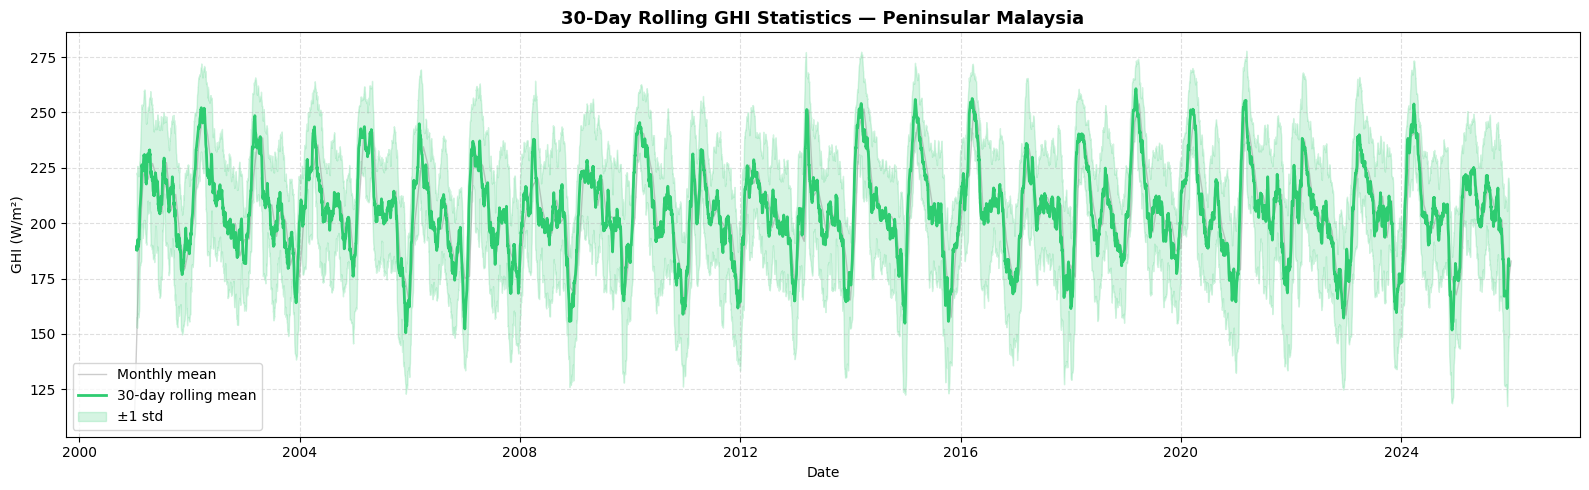

In [16]:
series = region_dfs["Peninsular Malaysia"]["ALLSKY_SFC_SW_DWN"]
roll   = series.rolling(30, center=True)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(series.resample("ME").mean(), alpha=0.4, color="gray", lw=1, label="Monthly mean")
ax.plot(roll.mean(), color="#2ECC71", lw=2, label="30-day rolling mean")
ax.fill_between(series.index, roll.mean()-roll.std(), roll.mean()+roll.std(),
                alpha=0.2, color="#2ECC71", label="±1 std")
ax.set_xlabel("Date"); ax.set_ylabel("GHI (W/m²)")
ax.set_title("30-Day Rolling GHI Statistics — Peninsular Malaysia", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### 7.10 Inter-Region Variable Distribution Boxplots

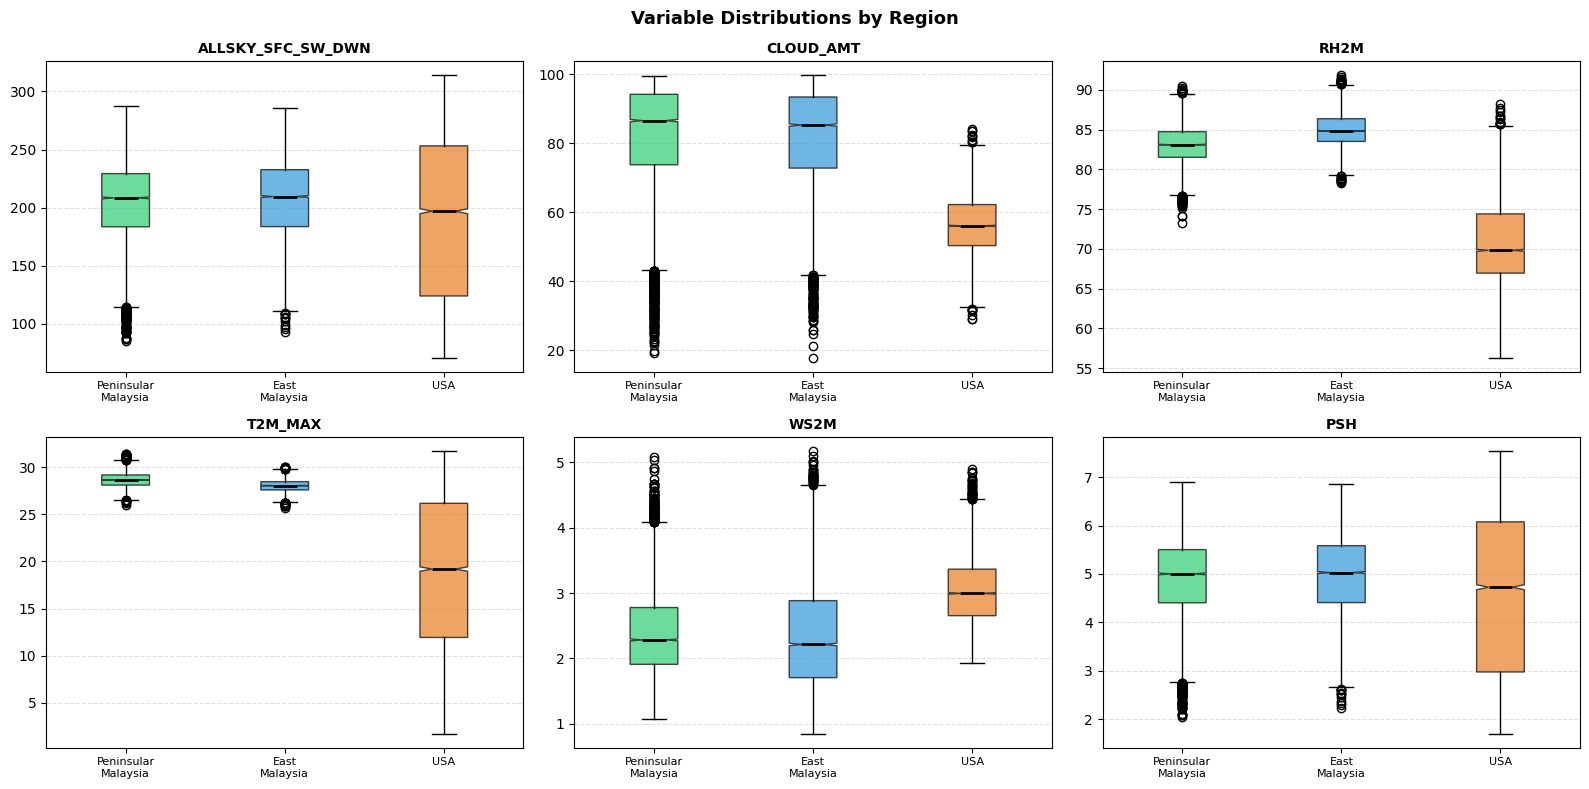

In [17]:
VARS_TO_PLOT = ["ALLSKY_SFC_SW_DWN", "CLOUD_AMT", "RH2M", "T2M_MAX", "WS2M", "PSH"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.flat, VARS_TO_PLOT):
    data_list = [region_dfs[r][var].dropna().values for r in region_dfs]
    bp = ax.boxplot(data_list, patch_artist=True, notch=True, medianprops=dict(color="black", lw=2))
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels([r.replace(" ", "\n") for r in region_dfs], fontsize=8)
    ax.set_title(var, fontsize=10, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.suptitle("Variable Distributions by Region", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 7.11 Outlier Detection (IQR Method) — Peninsular Malaysia

AOD_55               4.62
PW                   3.88
CLOUD_AMT            2.43
PS                   1.74
WS2M                 1.26
ALLSKY_KT            0.97
PSH                  0.89
ALLSKY_SFC_SW_DWN    0.88
T2M_MAX              0.68
RH2M                 0.57


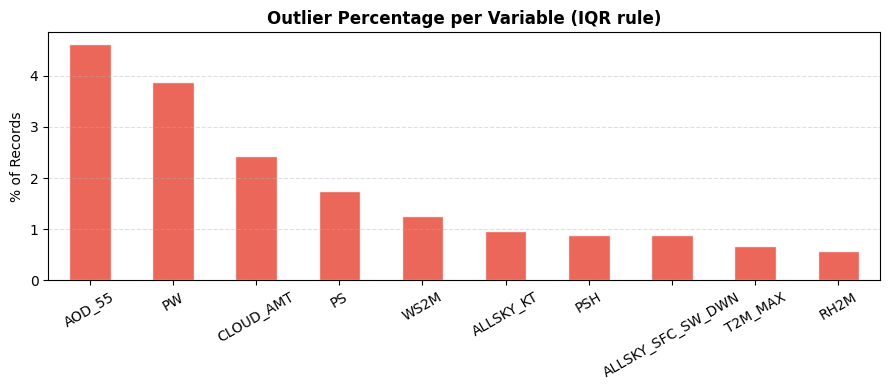

In [18]:
df_pm = region_dfs["Peninsular Malaysia"]
Q1, Q3 = df_pm.quantile(0.25), df_pm.quantile(0.75)
IQR = Q3 - Q1
outlier_pct = (((df_pm < Q1 - 1.5*IQR) | (df_pm > Q3 + 1.5*IQR)).sum() / len(df_pm) * 100).round(2)
print(outlier_pct.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
outlier_pct.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#E74C3C", edgecolor="white", alpha=0.85)
ax.set_title("Outlier Percentage per Variable (IQR rule)", fontsize=12, fontweight="bold")
ax.set_ylabel("% of Records"); ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### 7.12 Year-over-Year GHI Trend

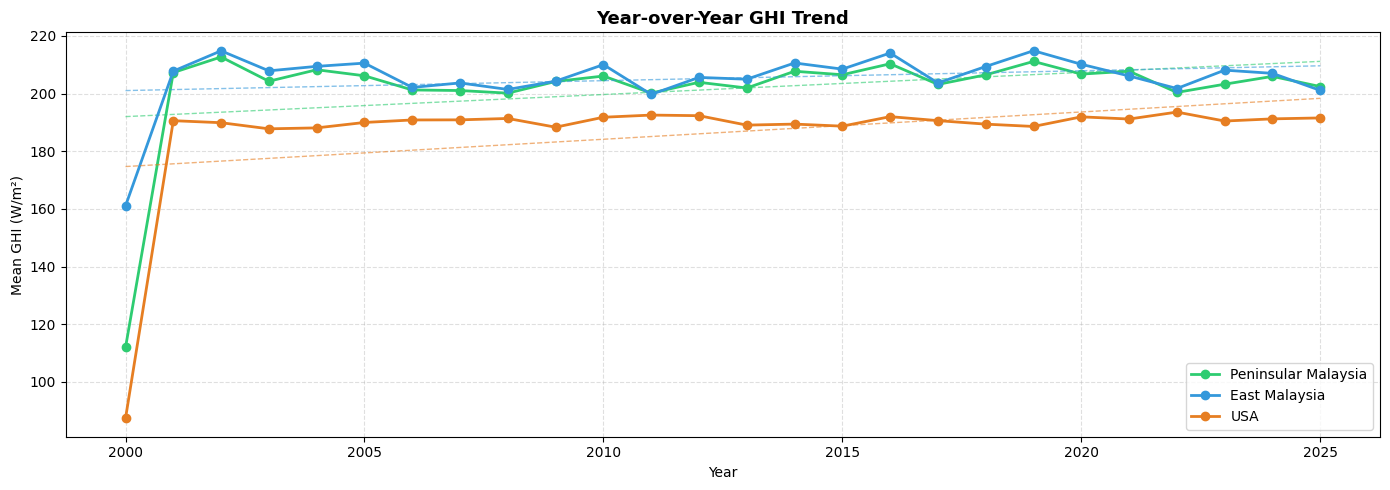

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
for (region, df), color in zip(region_dfs.items(), COLORS):
    yearly = df["ALLSKY_SFC_SW_DWN"].resample("YE").mean()
    ax.plot(yearly.index.year, yearly.values, marker="o", lw=2, color=color, label=region)
    m, b = np.polyfit(yearly.index.year, yearly.values, 1)
    ax.plot(yearly.index.year, m*yearly.index.year+b, "--", color=color, lw=1, alpha=0.6)
ax.set_xlabel("Year"); ax.set_ylabel("Mean GHI (W/m²)")
ax.set_title("Year-over-Year GHI Trend", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

## 8. Exploration Summary

| Finding | Detail |
|---------|--------|
| Regions | Peninsular Malaysia, East Malaysia, USA |
| Target variable | `ALLSKY_SFC_SW_DWN` — Global Horizontal Irradiance (W/m²) |
| Strongest predictors | `ALLSKY_KT`, `CLOUD_AMT`, `PSH` |
| Seasonality | Clear monthly patterns across all regions |
| Outliers | `CLOUD_AMT` and `AOD_55` have the highest outlier rates |
| Missing values | None after `dropna()` |
